# **HANDS - ON: EXPLORACIÓN DE DATOS**



Una vez visto la presentación ***Exploración de datos***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.

Para este notebook, se hará uso del siguiente dataset: [enlace](https://drive.google.com/file/d/1hX8uxJp5h03eYrgAnyznp8yeeG2syiD_/view?usp=drive_link)

De igual manera, se proporciona la **solución** de este notebook a través del siguiente [enlace](https://colab.research.google.com/drive/1eXIB1nd8aaBZWDYBXlIlfCOVkAe-ETrI?usp=drive_link).

## **ANÁLISIS EXPLORATPRIO**

El **Análisis Exploratorio de Datos (EDA)** es la etapa donde **se descubren patrones, se detectan anomalías y se comprueban hipótesis mediante estadísticas y visualizaciones**. Es el proceso fundamental para entender la salud de la información antes de cualquier toma de decisiones.

A través de herramientas descriptivas y gráficos de dispersión, esta fase permite limpiar inconsistencias y validar la calidad de la muestra. Su ejecución garantiza que las conclusiones posteriores se apoyen en evidencia real, minimizando sesgos y optimizando la precisión de los modelos predictivos.

In [1]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Importar datos
df_yt = pd.read_csv("./data/youtube_clean.csv")
df_yt

,video_id,título,categoría,views,likes,dislikes,comentarios,duración_min,fecha_publicación
0,1,título,música,129257,11299,21,8790,127,2024-07-02
1,2,título,películas,247904,15579,211,4775,63,2022-02-13
2,3,sin título,comedia,3073,14780,1095,9847,55,2016-07-06
3,4,título,gaming,268858,2691,4420,7614,78,2017-12-03
4,5,título,gaming,162893,16521,2294,6508,143,2023-11-24
...,...,...,...,...,...,...,...,...,...
303,106,título,películas,150272,11299,4605,6716,213,2021-09-04
304,131,título,tecnología,25407,9999999,2437,4498,137,2025-07-18
305,6,título,películas,42160,10721,3547,9033,58,2025-08-27
306,97,título,deportes,13530,14437,2631,2629,158,2018-03-12


In [3]:
# Ver resumen estadístico de las columnas numéricas
columnas_numericas = ['views', 'likes', 'dislikes', 'comentarios']
df_yt[columnas_numericas].describe()

,views,likes,dislikes,comentarios
count,308.000000,3.080000e+02,308.000000,308.000000
mean,144805.269481,6.265995e+05,12193.288961,5058.188312
std,86246.543475,2.407311e+06,52900.153300,2940.396104
min,1691.000000,9.700000e+01,21.000000,12.000000
25%,74129.500000,5.774250e+03,1523.750000,2667.500000
50%,129257.000000,1.129900e+04,2590.000000,4931.500000
75%,224050.750000,1.575300e+04,3777.500000,7740.750000
max,299408.000000,9.999999e+06,300408.000000,9987.000000


### **VALORES ATÍPICOS Y TRATAMIENTO**

**Los valores atípicos son observaciones que se alejan significativamente del resto de los datos**. Pueden ser causados por errores en la entrada de datos o por fenómenos naturales del dataset.

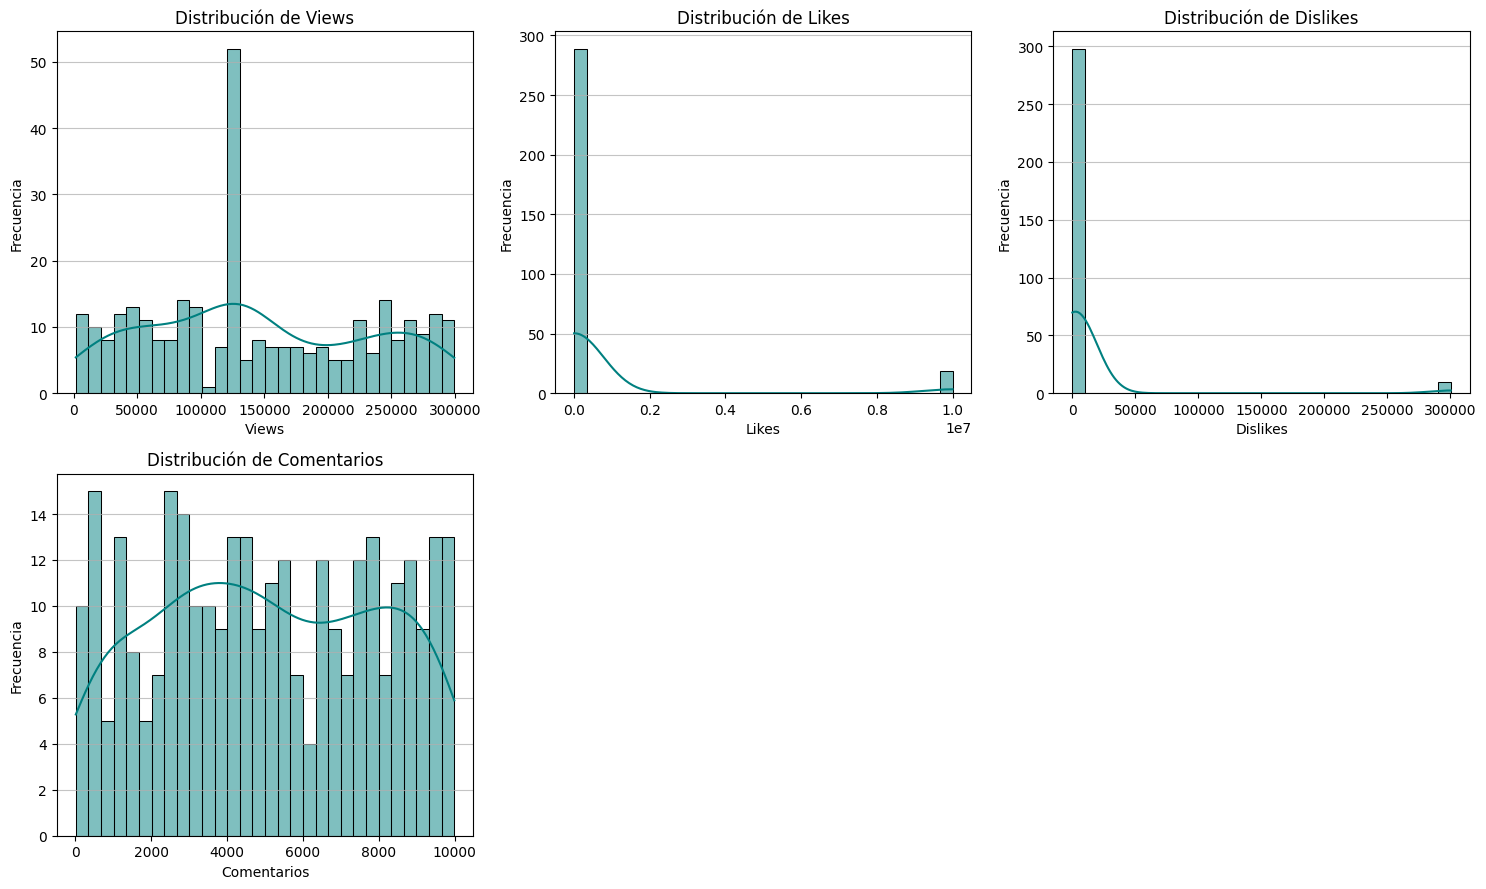

In [4]:
# Observar distribución de los datos
plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_yt[col], bins=30, kde=True, color='teal')
    plt.title(f'Distribución de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()


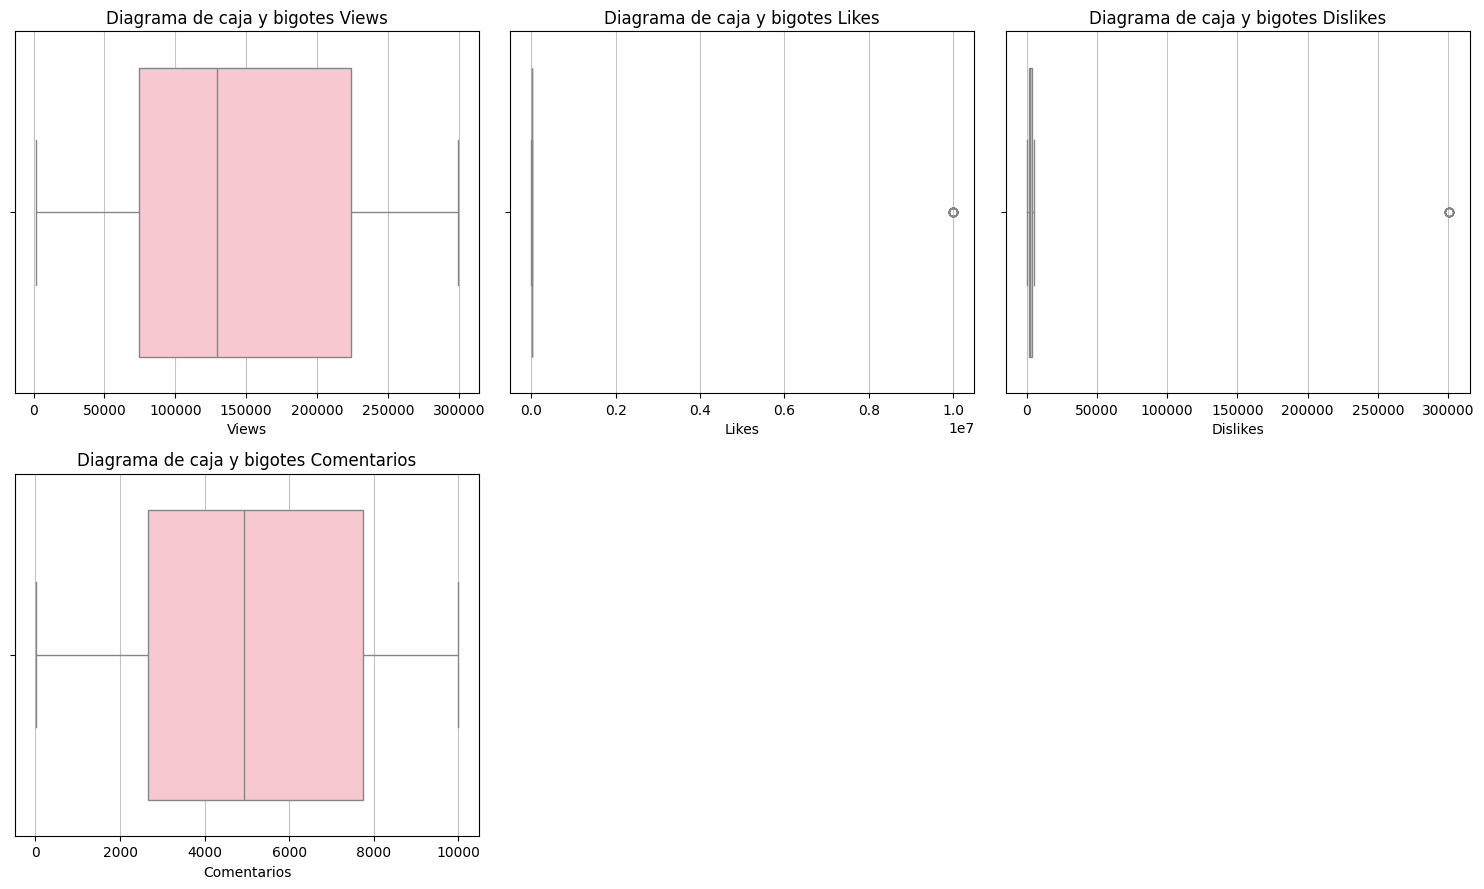

In [5]:
# Observar comportamiento cuartil de los datos
plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_yt[col], color='pink')
    plt.title(f'Diagrama de caja y bigotes {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

#### **RANGO INTERCUARTILICO**

El **Rango Intercuartílico (IQR)** es una medida fundamental de dispersión estadística, utilizada principalmente para detectar y manejar **valores atípicos (outliers)** en un conjunto de datos. Se calcula como la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1):

$$IQR = Q3 - Q1$$

Para identificar outliers, se definen límites:

*   **Límite Inferior (LI):** $LI = Q1 - 1.5 \times IQR$

*   **Límite Superior (LS):** $LS = Q3 + 1.5 \times IQR$


In [6]:
# Ver cantidad de registros iniciales
print(f"Cantidad de datos iniciales: {len(df_yt)}")

Cantidad de datos iniciales: 308


In [7]:
# Calculo del IQR
df_copy = df_yt.copy()

for col in columnas_numericas:

    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf_iqr = Q1 - 1.5 * IQR
    lim_sup_iqr = Q3 + 1.5 * IQR

    cant_inicial = len(df_copy)
    # Filtro de los datos dentro de los límites
    df_copy = df_copy[(df_copy[col] >= lim_inf_iqr) & (df_copy[col] <= lim_sup_iqr)]
    cant_final = len(df_copy)

    print(f"Columna '{col}': Se eliminaron {cant_inicial - cant_final} registros.")

Columna 'views': Se eliminaron 0 registros.
Columna 'likes': Se eliminaron 19 registros.
Columna 'dislikes': Se eliminaron 10 registros.
Columna 'comentarios': Se eliminaron 0 registros.


In [8]:
# Ver cantidad de registros finales y proporción con la cantidad inicial
prop_cant_datos = round((len(df_copy) / len(df_yt)) * 100, 2)

print(f"Cantidad de datos finales: {len(df_copy)}")
print(f"Los datos finales representan el {prop_cant_datos}% de los datos iniciales")

Cantidad de datos finales: 279
Los datos finales representan el 90.58% de los datos iniciales


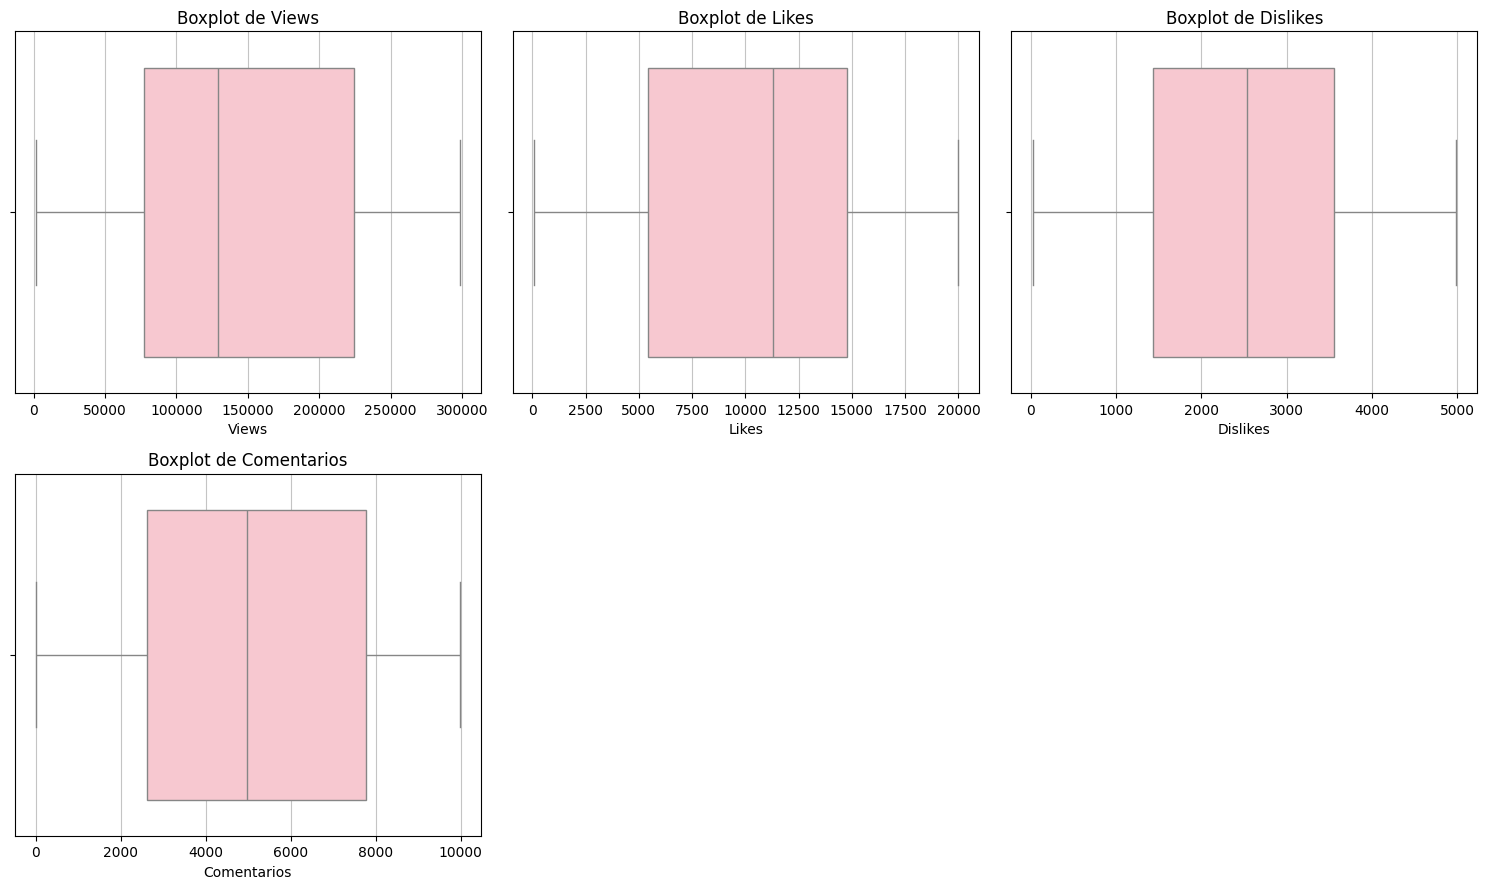

In [9]:
# Observar comportamiento cuartil final de los datos
plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_copy[col], color='pink')
    plt.title(f'Boxplot de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

### **CORRELACIÓN NUMÉRICA**

La **correlación numérica** es una medida estadística que **indica la fuerza y dirección de la relación lineal entre dos o más variables numéricas**. Puede utilizar el coeficiente de correlación de Pearson (el más común) para determinar la dirección (positiva, negativa, nula).

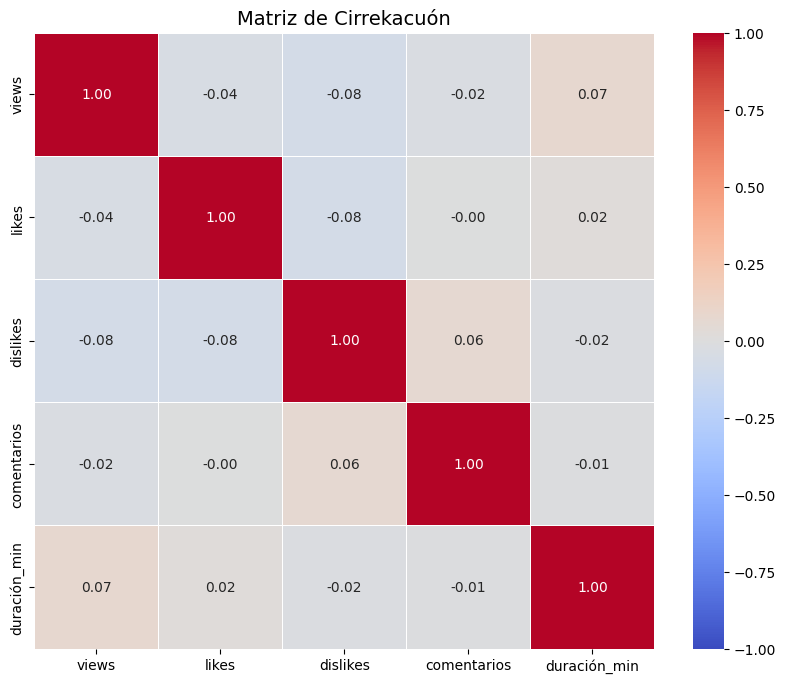

In [10]:
# Realizar matriz de correlación
corr_matrix = df_copy[['views', 'likes', 'dislikes', 'comentarios', 'duración_min']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Matriz de Cirrekacuón', fontsize=14)
plt.show()


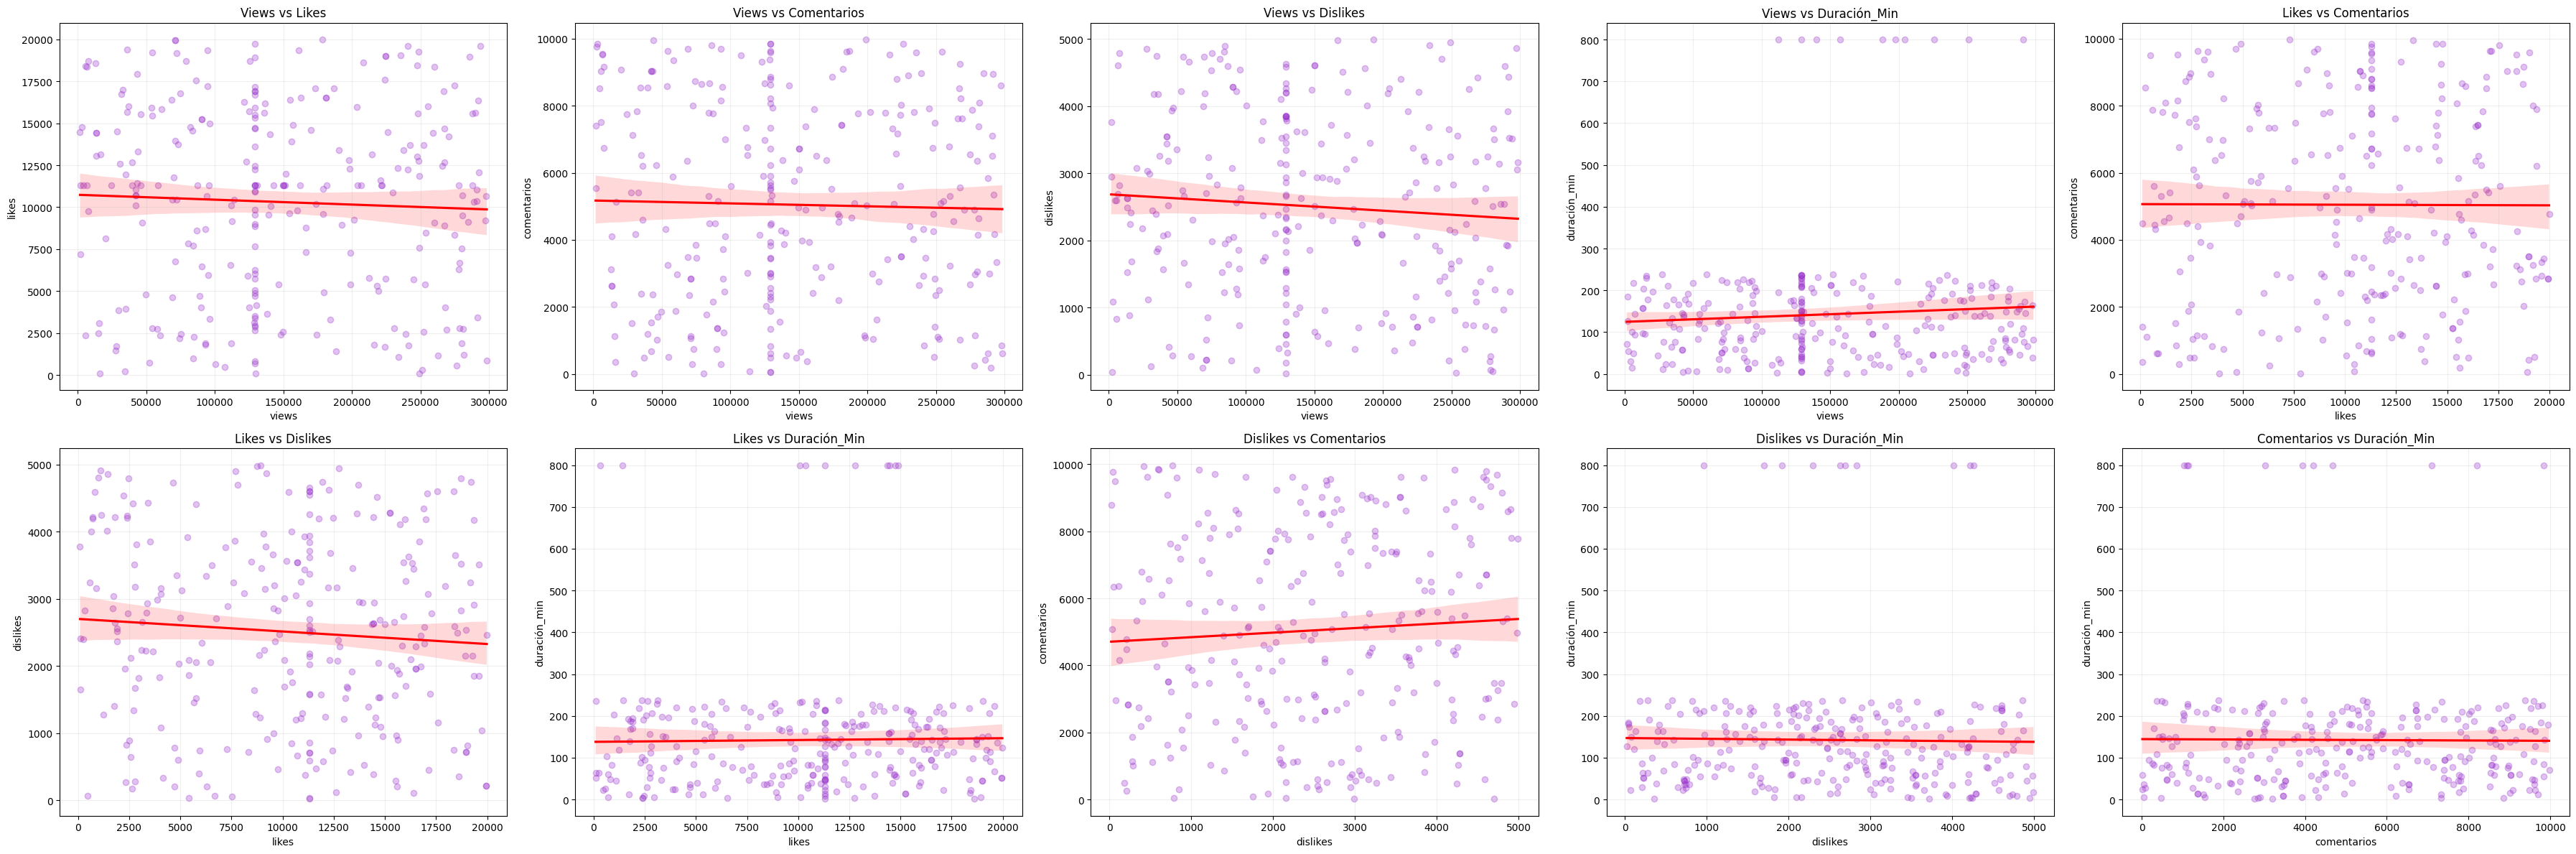

In [11]:
# Realizar correlaciones divididas
metricas = ['views', 'likes', 'dislikes', 'comentarios', 'duración_min']

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(36, 12))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# Pares de comparación por
comparaciones = [
    ('views', 'likes'), ('views', 'comentarios'), ('views', 'dislikes'),
    ('views', 'duración_min'), ('likes', 'comentarios'), ('likes', 'dislikes'),
    ('likes', 'duración_min'), ('dislikes', 'comentarios'),
    ('dislikes', 'duración_min'), ('comentarios', 'duración_min')
]

for i, (col_x, col_y) in enumerate(comparaciones):
    sns.regplot(ax=axes[i], data=df_copy, x=col_x, y=col_y,
                scatter_kws={'alpha':0.3, 'color':'darkorchid'},
                line_kws={'color':'red'})
    axes[i].set_title(f'{col_x.title()} vs {col_y.title()}')
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()

#### **COMPARACIÓN POR CATEGÓRICA**

La **comparación por categórica** implica analizar cómo las variables numéricas se comportan o distribuyen a través de diferentes grupos o categorías. Este tipo de análisis es fundamental para entender: **distribuciones, tendencias y relaciones**

Para visualizar estas comparaciones, son muy útiles los **gráficos de barras**, donde se pueden mostrar las cantidades o promedios de una variable numérica para cada categoría, o los **diagramas de caja (boxplots)**, que revelan la distribución completa de los datos dentro de cada grupo, incluyendo la mediana, cuartiles y posibles valores atípicos.

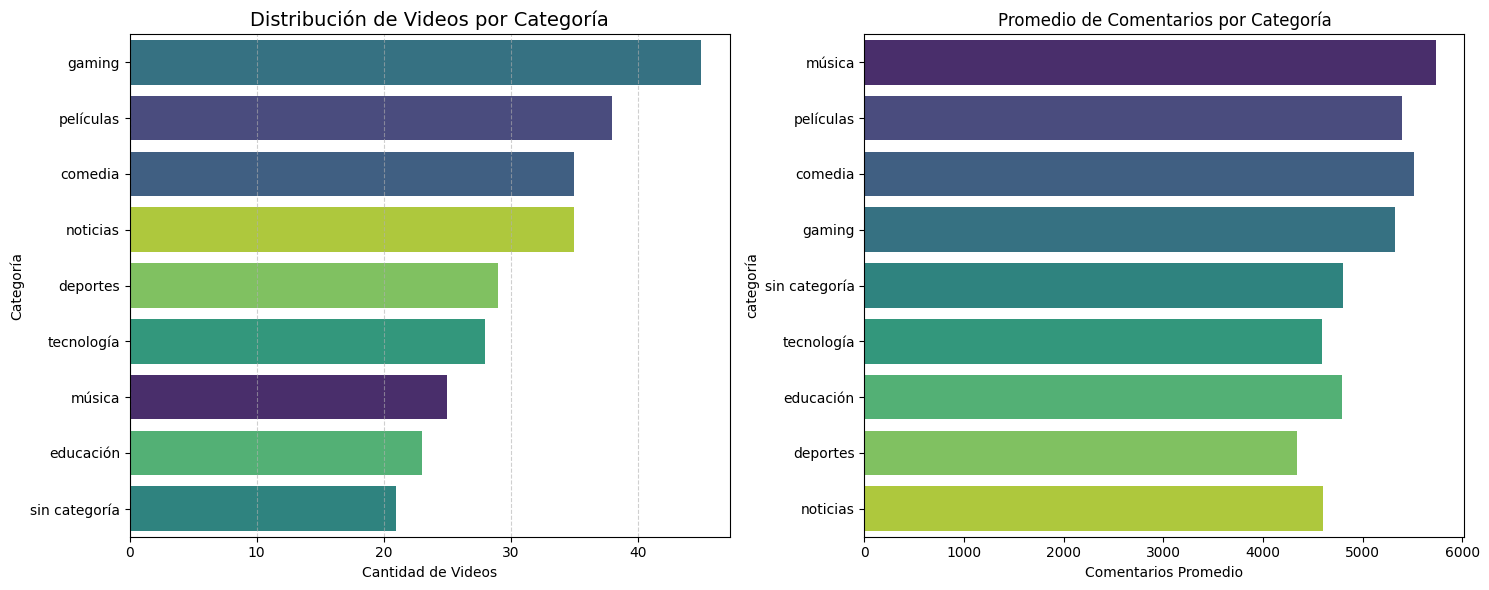

In [12]:
# Realizar gráficos de barras divididas
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
orden = df_copy['categoría'].value_counts().index # Ordenar de mayor a menor
sns.countplot(data=df_copy, y='categoría', order=orden, palette='viridis', hue='categoría', legend=False)
plt.title('Distribución de Videos por Categoría', fontsize=14)
plt.xlabel('Cantidad de Videos')
plt.ylabel('Categoría')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.barplot(data=df_copy, x='comentarios', y='categoría',
            estimator='mean', palette='viridis', errorbar=None, hue='categoría', legend=False)
plt.title('Promedio de Comentarios por Categoría')
plt.xlabel('Comentarios Promedio')

plt.tight_layout()
plt.show()

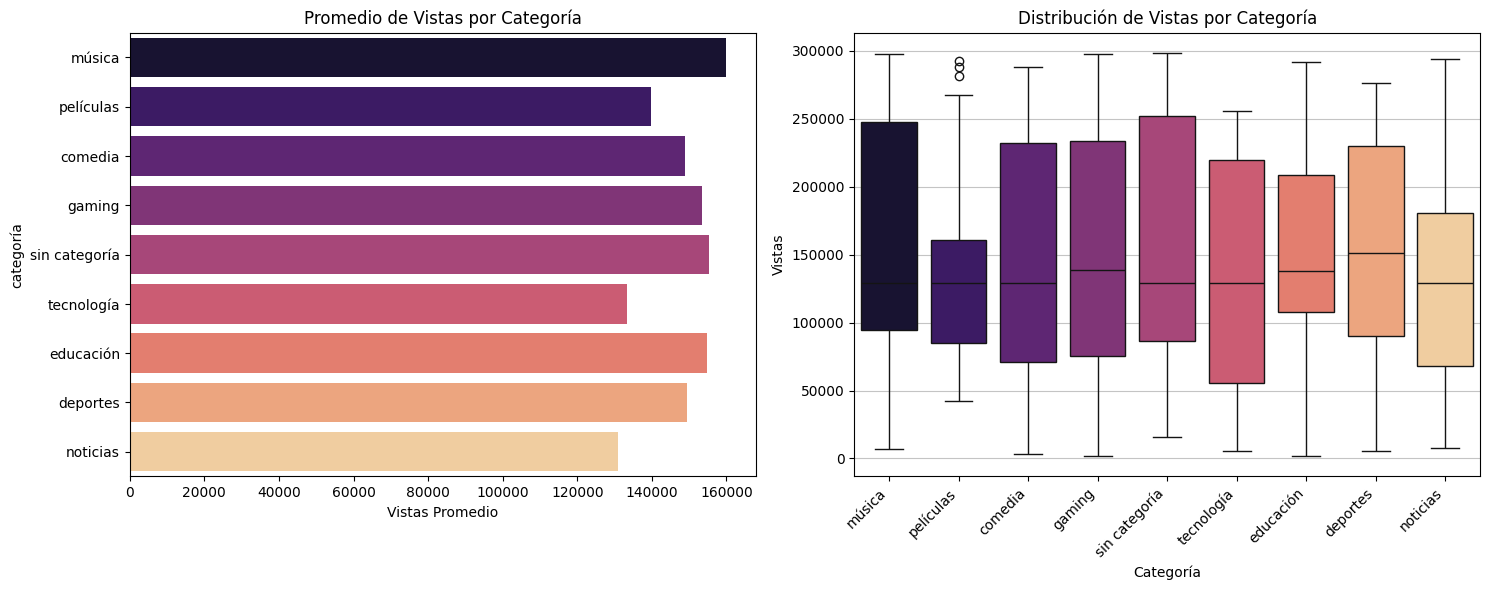

In [13]:
# Realizar gráfico de barras y caja divididos
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=df_copy, x='views', y='categoría',
            estimator='mean', palette='magma', errorbar=None, hue='categoría', legend=False)
plt.title('Promedio de Vistas por Categoría')
plt.xlabel('Vistas Promedio')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_copy, x='categoría', y='views', palette='magma', hue='categoría', legend=False)
plt.title('Distribución de Vistas por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Vistas')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

## **NARRATIVA VISUAL**

La **visualización narrativa** es la fusión estratégica entre la **claridad de los gráficos** y el **impacto del storytelling para comunicar mensajes** memorables. No se limita a exponer cifras, sino que construye un relato donde los datos actúan como evidencia para guiar a la audiencia hacia una conclusión clara.

Al conectar puntos de datos con una estructura narrativa, se logra captar la atención emocional y lógica del espectador. Esta técnica transforma estadísticas frías en una historia coherente, facilitando la comprensión de tendencias complejas y asegurando que los hallazgos clave impulsen una toma de decisiones informada.

### **PROPORCIÓN DE DATOS A MOSTRAR**

In [14]:
# Definir variables para la agrupación
categoria = lambda x: 'Sin Categoría' if x == 'sin categoría' else 'Con Categoría'
df_yt['agrupacion_cat'] = df_yt['categoría'].apply(categoria)
pie_data = df_yt['agrupacion_cat'].value_counts()

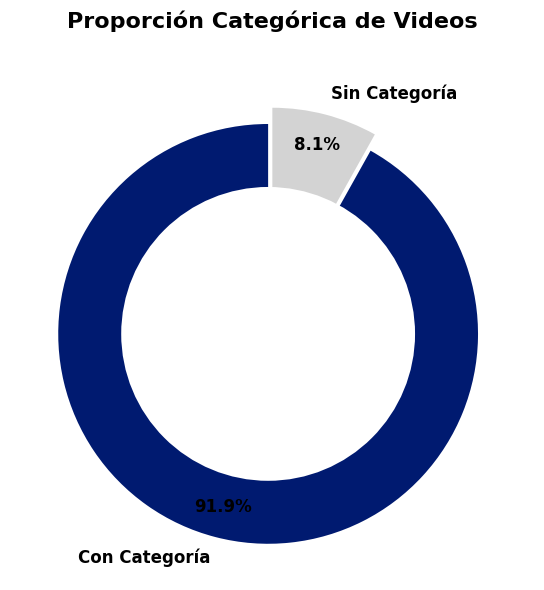

In [15]:
# Realizar gráfico de dona
colors_pie = ['#001a70', '#D3D3D3'] # Azul = "Con Categoría", Gris = "Sin Categoría"
explode_val = 0.08 # Valor de separación

# Gráfico de pastel
plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(pie_data,
                                labels=pie_data.index,
                                autopct='%1.1f%%',
                                startangle=90,
                                colors=colors_pie,
                                textprops={'fontsize': 12, 'fontweight': 'bold'},
                                pctdistance=0.85, # Mueve el porcentaje hacia afuera
                                explode=(explode_val, 0)) # Resalta ligeramente la porción principal

# Círculo blanco central (estilo moderno)

theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center_angle = np.deg2rad((theta1 + theta2) / 2) # Obtención el ángulo medio

cx = explode_val * np.cos(center_angle) # Se Calcula nueva posición con trigonometría
cy = explode_val * np.sin(center_angle)

centre_circle = plt.Circle((cx, cy), 0.70, fc='white') # Se dibuja el circulo
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proporción Categórica de Videos', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### **DISTRIBUCIÓN DE VÍDEOS POR CATEGORÍA**

In [16]:
# Definir variables
df_filtrado = df_yt[df_yt['categoría'] != 'sin categoría']
counts = df_filtrado['categoría'].value_counts()
order = counts.index
values = counts.values

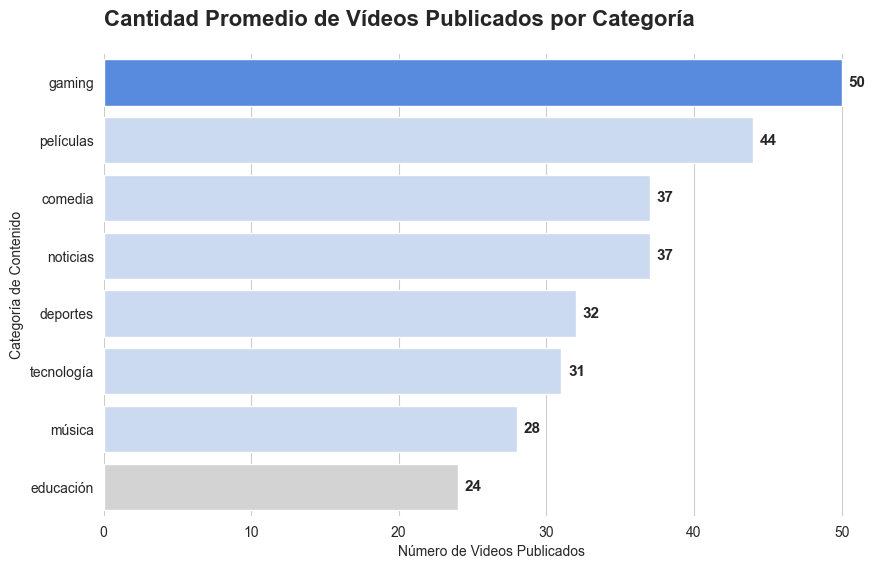

In [17]:
# Realizar gráfico de barras
colors = ['#4285F4' if v == values.max() else '#D3D3D3' if v == values.min() else '#C6D9F7' for v in values]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=values, y=order, palette=colors, hue=order, legend=False)

for p in ax.patches: # Etiquetas de datos
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=11, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Cantidad Promedio de Vídeos Publicados por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Videos Publicados')
plt.ylabel('Categoría de Contenido')
sns.despine(left=True, bottom=True)
plt.show()

### **PROMEDIO DE VISTAS POR CATEGORÍA**

In [18]:
# Definir variables
vistas_mean = df_yt.groupby('categoría')['views'].mean().sort_values(ascending=False)
colors_vistas = ['#4285F4' if v == vistas_mean.max() else '#D3D3D3' if v == vistas_mean.min() else '#C6D9F7' for v in vistas_mean]

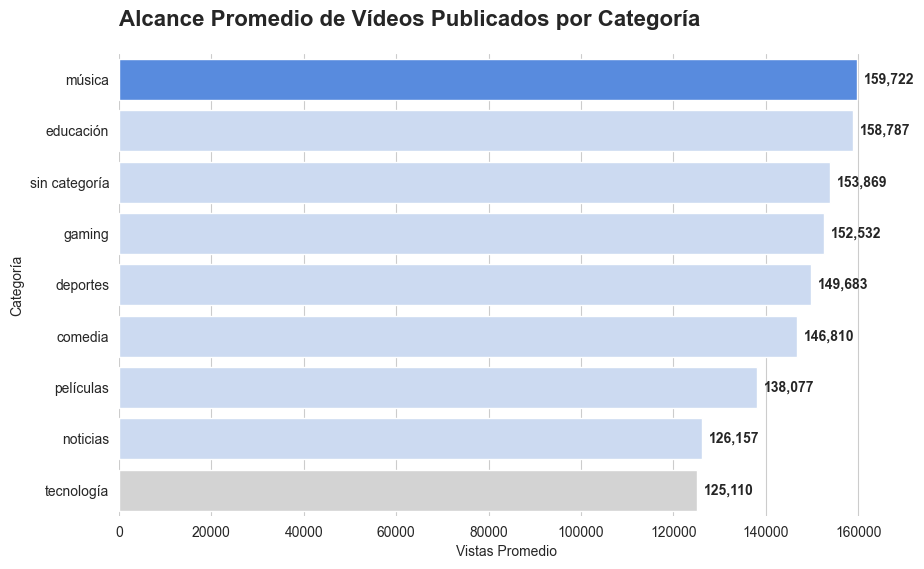

In [19]:
# Realizar gráfico de barras
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax1 = sns.barplot(x=vistas_mean.values, y=vistas_mean.index, palette=colors_vistas, hue=vistas_mean.index, legend=False)

for p in ax1.patches: # Etiquetas y estética
    ax1.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Alcance Promedio de Vídeos Publicados por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Vistas Promedio')
plt.ylabel('Categoría')
sns.despine(left=True, bottom=True)
plt.show()

### **PROMEDIO DE COMENTARIOS POR CATEGORÍA**

In [20]:
# Definir variables
coments_mean = df_yt.groupby('categoría')['comentarios'].mean().sort_values(ascending=False)
colors_coments = ['#4285F4' if v == coments_mean.max() else '#D3D3D3' if v == coments_mean.min() else '#C6D9F7' for v in coments_mean]

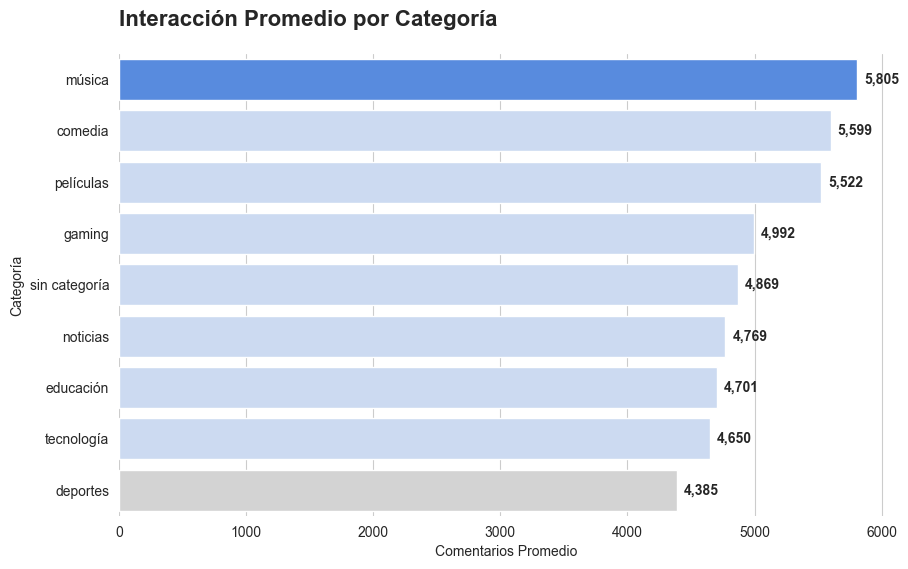

In [43]:
# Realizar gráfico de barras
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax2 = sns.barplot(x=coments_mean.values, y=coments_mean.index, palette=colors_coments, hue=coments_mean.index, legend=False)

for p in ax2.patches: # Etiquetas y estética
    ax2.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Interacción Promedio por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Comentarios Promedio')
plt.ylabel('Categoría')
sns.despine(left=True, bottom=True)
plt.show()

## **CHALLENGE: EXPLORACIÓN DE DATOS AIRBNB CDMX**

Una vez visto el ***Hands - On: Exploración de datos***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Para este notebook, se hará uso del siguiente dataset: [enlace](https://drive.google.com/file/d/1HKCV2jFnumpJ1YNFI5cn6wgT2tEiKKfK/view?usp=drive_link)

Dentro de la siguiente dinámica, **se realizará un análisis exploratorio profundo sobre el catálogo de alojamientos de Airbnb en la Ciudad de México** para detectar patrones de comportamiento, valores atípicos y relaciones entre variables. Se hará uso de **herramientas estadísticas, técnicas de detección de outliers y narrativa visual** a través del dataset **"airbnb_clean"**.

Donde los análisis a realizar son:

* **Detección y tratamiento de valores atípicos mediante el rango intercuartílico**.
* **Identificación de relaciones lineales entre variables numéricas**.
* **Comunicación de hallazgos a través de narrativa visual por categoría**.

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importaciones y análisis de resumen estadístico:**

* Carga las bibliotecas de Pandas, Numpy, Seaborn y Matplotlib.pyplot.
* Carga el archivo *airbnb_clean.csv*.
* Obtén el resumen estadístico de los datos.

In [22]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [46]:
# Importar datos
df_airbnb  = pd.read_csv("./data/airbnb_clean.csv")
df_airbnb 

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,35797,Villa Dante,153786,Dici,Cuajimalpa de Morelos,19.382830,-99.271780,Entire home/apt,3673.0,1,0,Never reviewed,0.00,1,363,0
1,44616,Condesa Haus,196253,Fernando,Cuauhtémoc,19.411620,-99.177940,Entire home/apt,18000.0,1,65,2025-01-01,0.38,9,360,1
2,56074,Great space in historical San Rafael,265650,Maris,Cuauhtémoc,19.439770,-99.156050,Entire home/apt,591.0,15,84,2025-02-27,0.48,1,333,1
3,67703,"2 bedroom apt. deco bldg, Condesa",334451,Nicholas,Cuauhtémoc,19.411520,-99.168570,Entire home/apt,1039.0,2,50,2024-10-30,0.30,2,252,1
4,70644,Beautiful light Studio Coyoacan- full equipped !,212109,Trisha,Coyoacán,19.354480,-99.162170,Entire home/apt,1039.0,3,134,2025-08-18,0.81,3,234,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27046,1518356968266486778,Suite Frida,674644167,Heyliana,Venustiano Carranza,19.442240,-99.113440,Private room,1096.0,1,0,Never reviewed,0.00,5,365,0
27047,1518388105556721163,Habitación a un costado de Ciudad Universitaria,222854336,Marco Antonio,Coyoacán,19.308017,-99.168158,Private room,260.0,1,0,Never reviewed,0.00,1,365,0
27048,1518433354720281854,Espacioso departamento en Anzures,470800231,Hector Fernando,Miguel Hidalgo,19.434460,-99.174010,Entire home/apt,996.0,1,0,Never reviewed,0.00,20,365,0
27049,1518462568893975567,Casa Roma Baja 05,710857718,Camila,Cuauhtémoc,19.406435,-99.160934,Entire home/apt,458.0,1,0,Never reviewed,0.00,7,363,0


In [47]:
# Ver resumen estadístico
df_airbnb.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,2.705100e+04,2.705100e+04,27051.000000,27051.000000,27051.000000,27051.000000,27051.000000,27051.000000,27051.000000,27051.000000,27051.000000
mean,7.003556e+17,2.429439e+08,19.405490,-99.165385,1695.489483,4.580866,53.777679,1.621652,14.559868,232.686333,15.691028
std,5.702714e+17,2.062579e+08,0.042390,0.033535,12352.097771,24.784605,85.143043,2.219818,31.892178,122.270858,23.615517
min,3.579700e+04,7.365000e+03,19.177848,-99.339630,61.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,4.410472e+07,5.621443e+07,19.392489,-99.178499,700.000000,1.000000,4.000000,0.210000,1.000000,140.000000,0.000000
50%,8.307368e+17,1.766835e+08,19.415390,-99.167100,1039.000000,2.000000,21.000000,1.000000,3.000000,269.000000,7.000000
75%,1.217382e+18,4.288830e+08,19.432015,-99.153731,1484.000000,2.000000,69.000000,2.370000,11.000000,341.000000,23.000000
max,1.518561e+18,7.208445e+08,19.561010,-98.963360,900000.000000,1125.000000,1434.000000,119.460000,221.000000,365.000000,665.000000


**2. Análisis de distribución y filtrado de outliers:**

* Genera un histograma y diagrama de caja sobre la columna `price`.
* Calcula la cantidad de registros con los que cuenta el dataframe.
* Calcula el rango intercuartílico y filtra el dataframe con los registros dentro de los límites.
* Calcula la cantidad y proporción de registros finales y grafica su diagrama de caja.

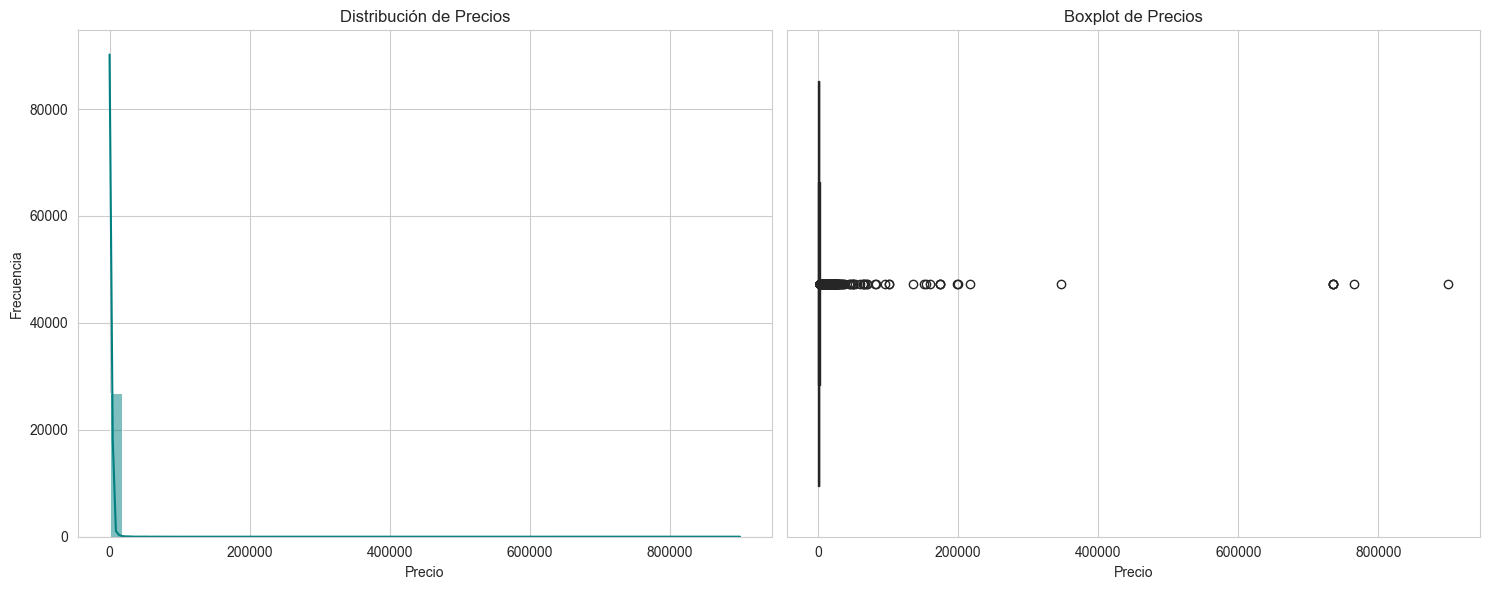

In [48]:
# Observar distribución y comportamiento cuartil de los datos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma con KDE
sns.histplot(df_airbnb['price'], bins=50, kde=True, color='teal', ax=axes[0])
axes[0].set_title('Distribución de Precios')
axes[0].set_xlabel('Precio')
axes[0].set_ylabel('Frecuencia')

# Boxplot
sns.boxplot(x=df_airbnb['price'], color='teal', ax=axes[1])
axes[1].set_title('Boxplot de Precios')
axes[1].set_xlabel('Precio')

plt.tight_layout()
plt.show()
plt.show()

In [49]:
# Ver cantidad de registros iniciales
registros_iniciales = len(df_airbnb)
print(f'Registros iniciales: {registros_iniciales}')

Registros iniciales: 27051


In [50]:
# Calculo del IQR
Q1 = df_airbnb['price'].quantile(0.25)
Q3 = df_airbnb['price'].quantile(0.75)
IQR = Q3 - Q1
LI = Q1 - 1.5 * IQR
LS = Q3 + 1.5 * IQR

df_airbnb = df_airbnb[(df_airbnb['price'] >= LI) & (df_airbnb['price'] <= LS)]
print(f'Límite Inferior: {LI} \nLímite Superior: {LS}')

Límite Inferior: -476.0 
Límite Superior: 2660.0


In [51]:
# Ver cantidad y proporción con la cantidad inicial
registros_finales = len(df_airbnb)
proporcion = registros_finales / registros_iniciales

print(f'Registros finales: {registros_finales}')
print(f'Proporción retenida: {proporcion:.2%}')

Registros finales: 24741
Proporción retenida: 91.46%


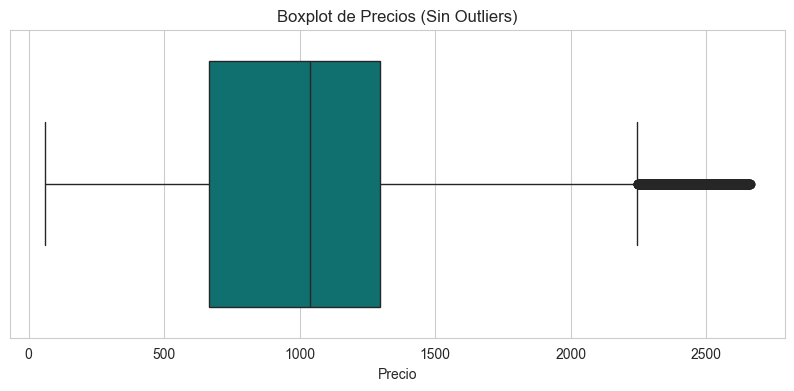

In [52]:
# Observar comportamiento cuartil final de los datos
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_airbnb['price'], color='teal')

plt.title('Boxplot de Precios (Sin Outliers)')
plt.xlabel('Precio')
plt.show()

**3. Análisis de correlaciones:**

* Genera una matriz de correlación sobre las columnas numéricas del dataframe.
* Selecciona las variables numéricas más representativas.
* Realiza correlaciones divididas por categoría segmentadas por la columna `room_type`.

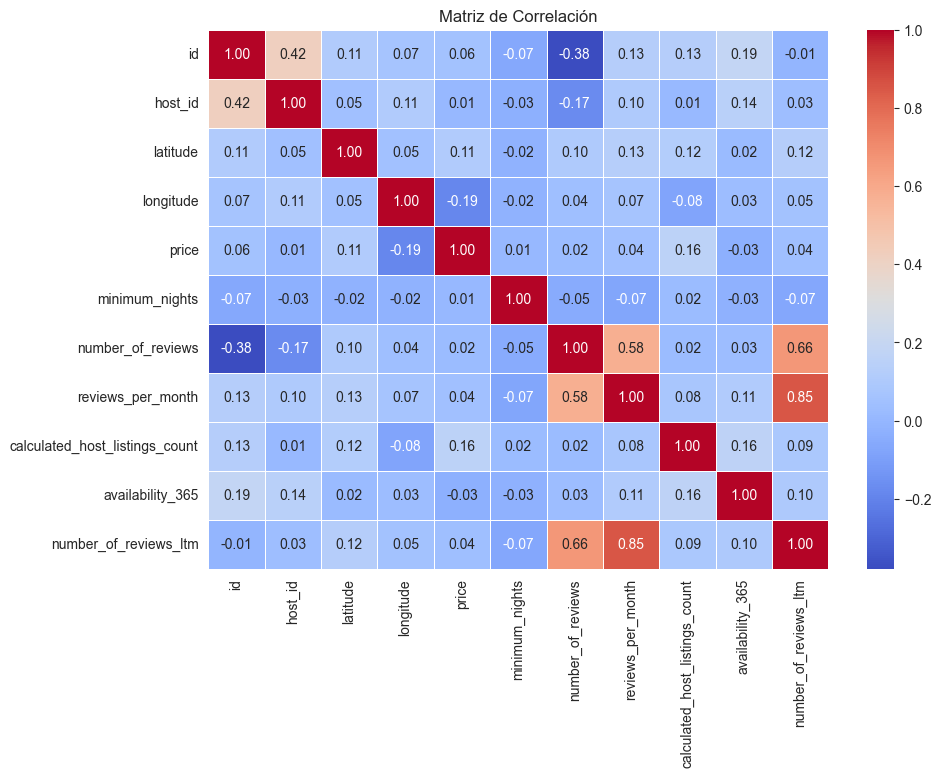

In [53]:
# Realizar matriz de correlación
columnas_numericas = df_airbnb.select_dtypes(include=['int64', 'float64']).columns
matriz_corr = df_airbnb[columnas_numericas].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

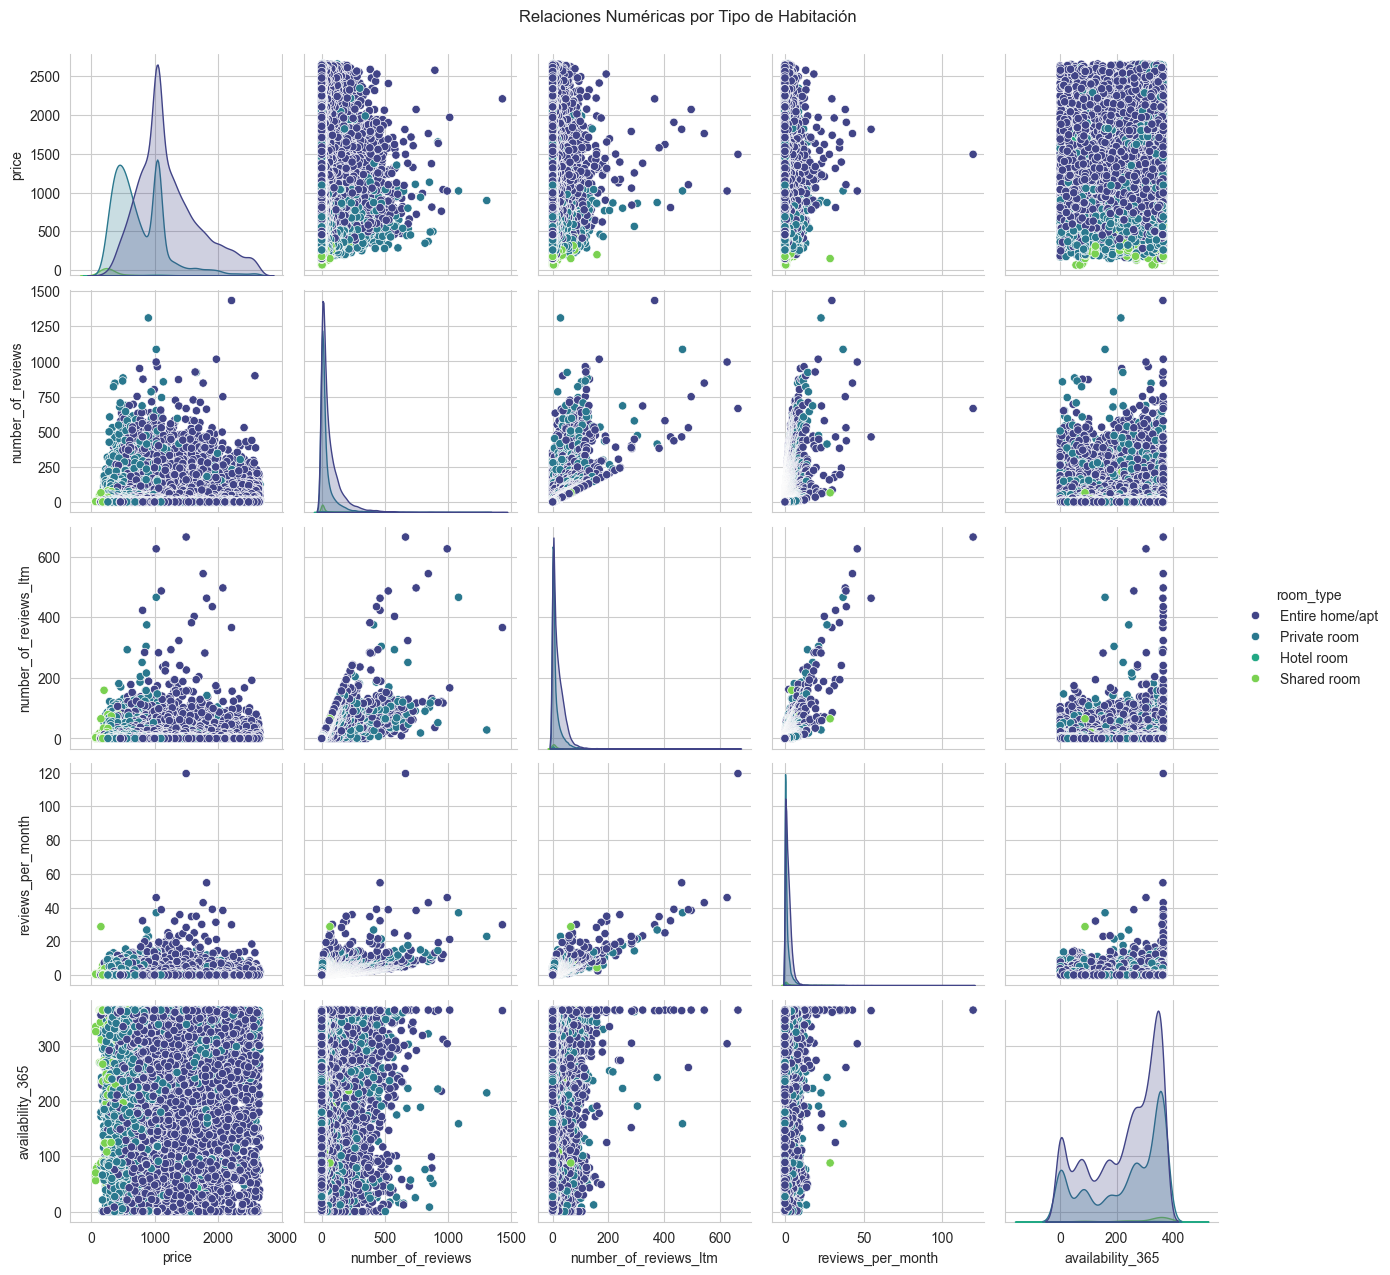

In [54]:
# Realizar correlaciones divididas
variables = ['price', 'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month', 'availability_365', 'room_type']

sns.pairplot(df_airbnb[variables], hue='room_type', palette='viridis')
plt.suptitle('Relaciones Numéricas por Tipo de Habitación', y=1.02)
plt.show()

**4. Regresión lineal simple:**

* Define como variable independiente `reviews_per_month` y como dependiente `number_of_reviews_ltm`.
* Calcula los coeficientes para determinar la ecuación del modelo de regresión lineal simple.
* Ajusta el modelo de regresión lineal con descenso de gradiente y determina la nueva ecuación.
* Visualizar el modelo de regresión lineal ajustada y la curva de perdidas.
* Calcula la reducción del error desde la primera hasta la última época.


In [55]:
# Cálculo de la regresión lineal simple
X = df_airbnb['reviews_per_month'].values
y = df_airbnb['number_of_reviews_ltm'].values
n = len(X)

coeficientes = np.polyfit(X, y, 1)
m, b = coeficientes
y_predicho = np.polyval(coeficientes, X)

print(f'Ecuación: y = {m:.4f}x + {b:.4f}')

Ecuación: y = 9.0574x + 1.0101


In [56]:
# Calculo del descenso de gradiente
m_grad = 0.0
b_grad = 0.0
learning_rate = 0.01
epocas = 100
historial_perdida = []

for epoca in range(epocas):

    y_pred = m_grad * X + b_grad  # Predicción
    perdida = np.mean((y - y_pred) ** 2) # Error cuadrático medio
    historial_perdida.append(perdida)

    grad_m = (-2/n) * np.sum(X * (y - y_pred)) # Gradientes
    grad_b = (-2/n) * np.sum(y - y_pred)

    m_grad -= learning_rate * grad_m # Actualizar parámetros
    b_grad -= learning_rate * grad_b

print(f'Ecuación: y = {m_grad:.4f}x + {b_grad:.4f}')

Ecuación: y = 8.9921x + 1.2969


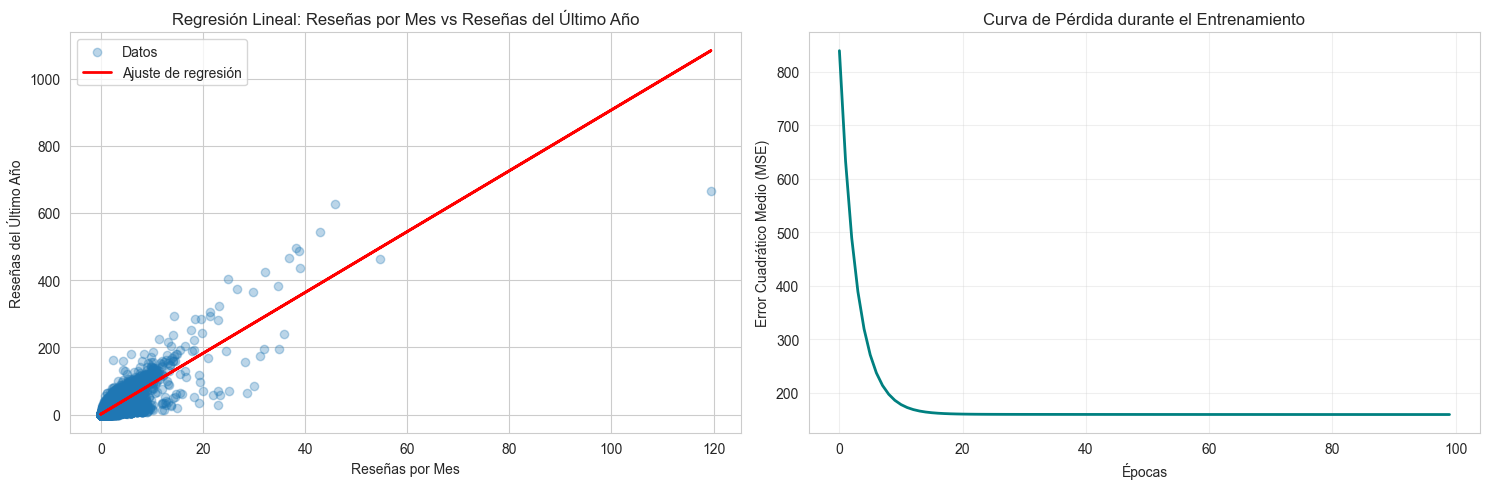

In [57]:
# Visualizar regresión lineal y perdidas
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Regresión Lineal
axes[0].scatter(X, y, alpha=0.3, label='Datos')
axes[0].plot(X, y_predicho, color = 'red', linewidth=2, label='Ajuste de regresión')
axes[0].set_title('Regresión Lineal: Reseñas por Mes vs Reseñas del Último Año')
axes[0].set_xlabel('Reseñas por Mes')
axes[0].set_ylabel('Reseñas del Último Año')
axes[0].legend()

# Gráfico 2: Curva de Pérdida
axes[1].plot(range(epocas), historial_perdida, color='teal', linewidth=2)
axes[1].set_title('Curva de Pérdida durante el Entrenamiento')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Error Cuadrático Medio (MSE)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [58]:
# Registro final de perdida
print(f'Pérdida inicial: {historial_perdida[0]:.4f}')
print(f'Pérdida final:   {historial_perdida[-1]:.4f}')
print(f'Reducción del error: {(1 - historial_perdida[-1]/historial_perdida[0])*100:.2f}%')

Pérdida inicial: 839.4546
Pérdida final:   159.5199
Reducción del error: 81.00%


**5. Comparación por categoría:**

* Utiliza un gráfico de barras para mostrar el precio promedio por tipo de habitación.
* Utiliza un diagrama de caja para visualizar la distribución del precio por tipo de habitación.
* Agrupa el dataframe por la columna `room_type` y calcula el conteo de alojamientos.
* Utiliza un gráfico de dona que muestre el porcentaje de cada categoría.

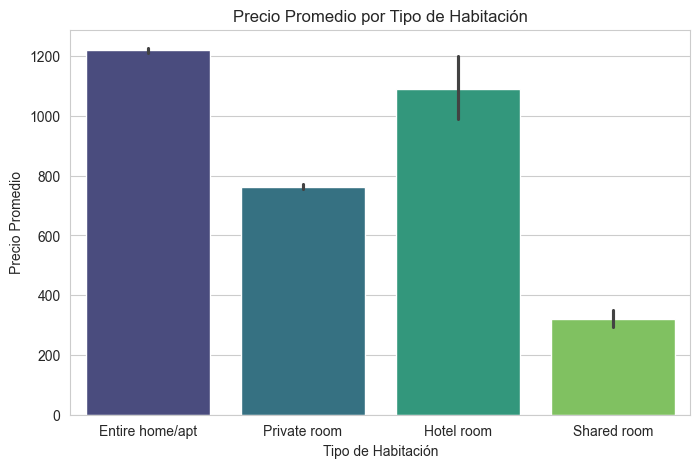

In [59]:
# Realizar gráficos de barras divididas
plt.figure(figsize=(8, 5))
sns.barplot(data=df_airbnb, x='room_type', y='price', hue='room_type', palette='viridis', legend=False)

plt.title('Precio Promedio por Tipo de Habitación')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Precio Promedio')
plt.show()

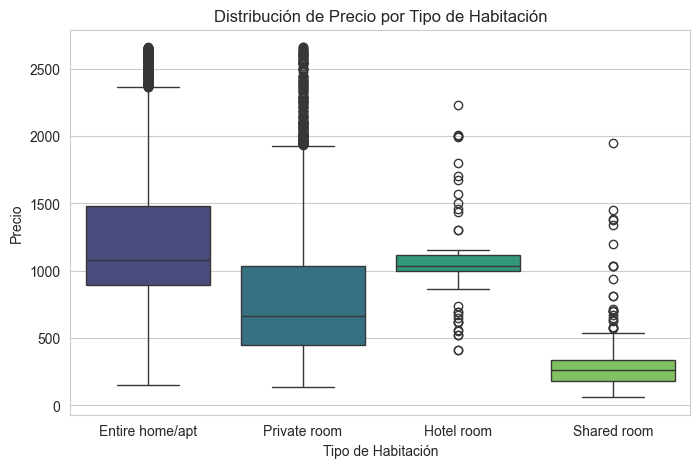

In [60]:
# Realizar gráfico de barras y caja divididos
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_airbnb, x='room_type', y='price', hue='room_type', palette='viridis', legend=False)

plt.title('Distribución de Precio por Tipo de Habitación')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Precio')
plt.show()

In [61]:
# Definir variables para la agrupación
conteo_room_type = df_airbnb['room_type'].value_counts()
etiquetas = conteo_room_type.index
valores = conteo_room_type.values

print(conteo_room_type)

room_type
Entire home/apt    15726
Private room        8699
Shared room          256
Hotel room            60
Name: count, dtype: int64


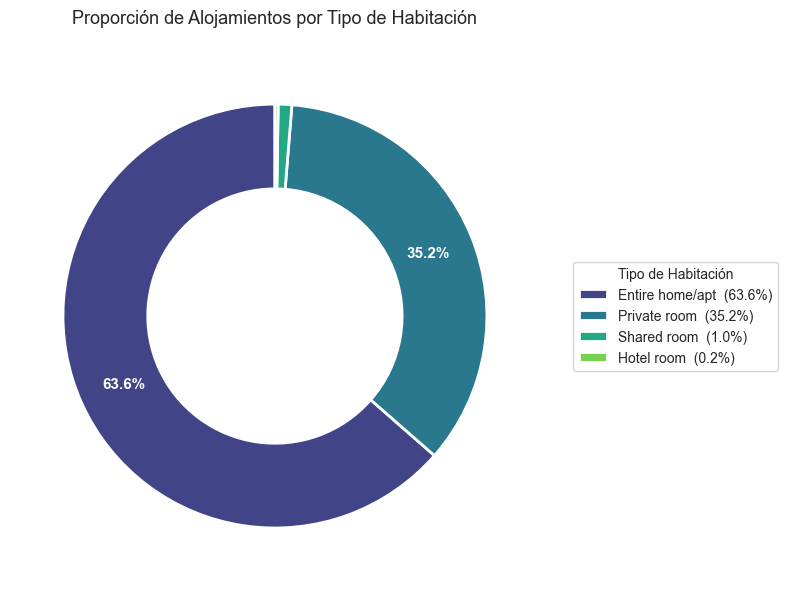

In [62]:
# Realizar gráfico de dona
plt.figure(figsize=(8, 8))
colores = sns.color_palette('viridis', len(etiquetas))

# Solo mostrar el porcentaje en categorías con valor significativo (>2%)
def autopct_filtrado(pct):
    return f'{pct:.1f}%' if pct > 2 else ''

wedges, texts, autotexts = plt.pie(
    valores,
    labels=None,
    autopct=autopct_filtrado,
    colors=colores,
    startangle=90,
    pctdistance=0.78,
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2}
)

# Estilo del texto de los porcentajes internos
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

# Leyenda externa con todas las categorías y su porcentaje
total = sum(valores)
leyenda = [f'{etiqueta}  ({valor/total*100:.1f}%)' for etiqueta, valor in zip(etiquetas, valores)]
plt.legend(wedges, leyenda, title='Tipo de Habitación', loc='center left', bbox_to_anchor=(1.05, 0.5))

plt.title('Proporción de Alojamientos por Tipo de Habitación', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

**6. Narrativa visual:**

* Utiliza un gráfico de barras horizontales para mostrar el conteo de alojamientos por alcaldía.
* Utiliza un gráfico de barras horizontales para mostrar el precio promedio por alcaldía.
* Utiliza un gráfico de barras horizontales para mostrar el promedio de reseñas por alcaldía.

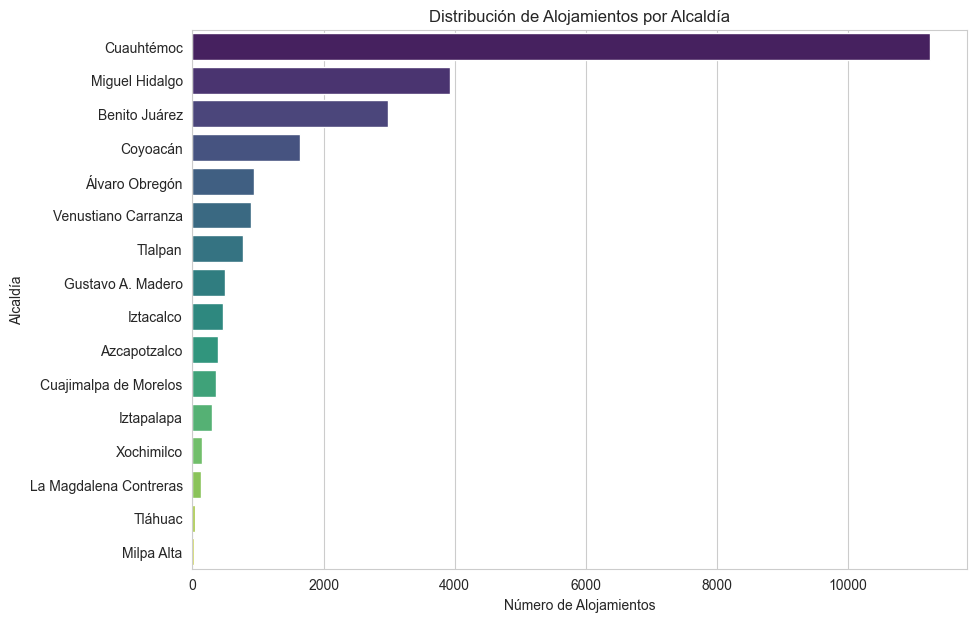

In [63]:
# Realizar gráfico de barras
conteo_alcaldia = df_airbnb['neighbourhood'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=conteo_alcaldia.values, y=conteo_alcaldia.index, hue=conteo_alcaldia.index, palette='viridis', legend=False)

plt.title('Distribución de Alojamientos por Alcaldía')
plt.xlabel('Número de Alojamientos')
plt.ylabel('Alcaldía')
plt.show()

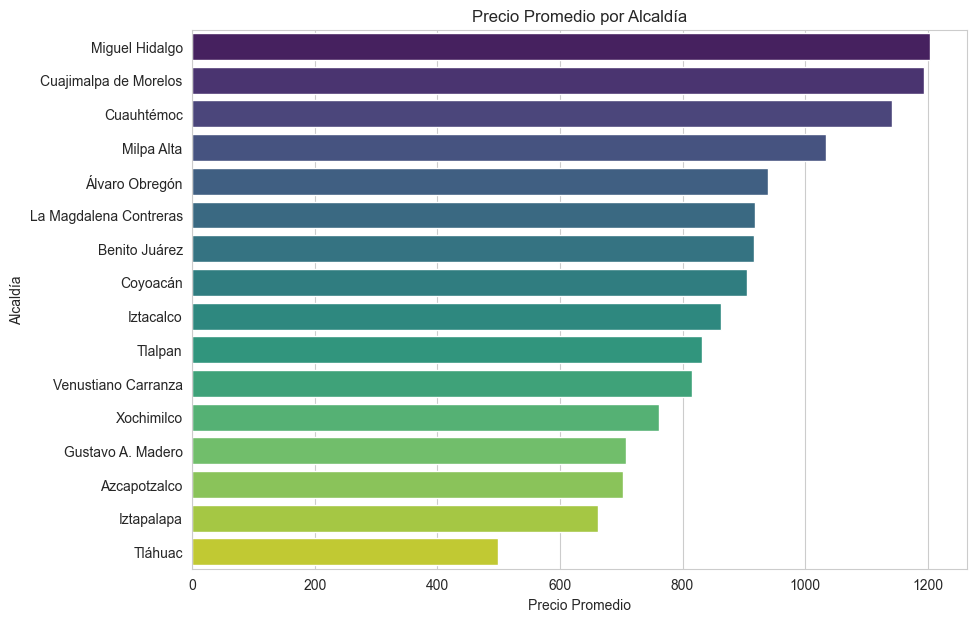

In [64]:
# Realizar gráfico de barras
precio_alcaldia = df_airbnb.groupby('neighbourhood', observed=True)['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=precio_alcaldia.values, y=precio_alcaldia.index, hue=precio_alcaldia.index, palette='viridis', legend=False)

plt.title('Precio Promedio por Alcaldía')
plt.xlabel('Precio Promedio')
plt.ylabel('Alcaldía')
plt.show()

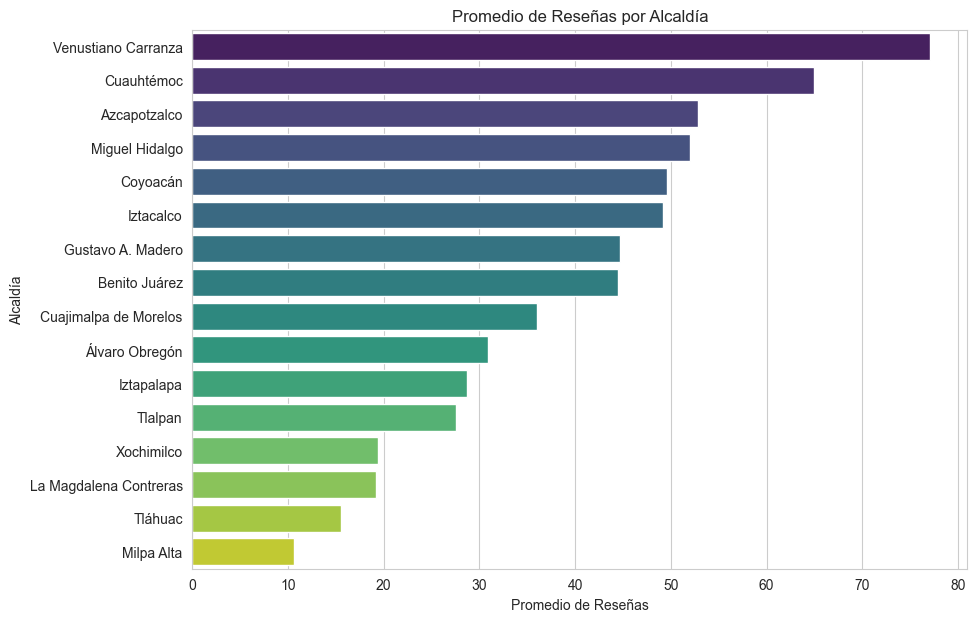

In [65]:
# Realizar gráfico de barras
reviews_alcaldia = df_airbnb.groupby('neighbourhood', observed=True)['number_of_reviews'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=reviews_alcaldia.values, y=reviews_alcaldia.index, hue=reviews_alcaldia.index, palette='viridis', legend=False)

plt.title('Promedio de Reseñas por Alcaldía')
plt.xlabel('Promedio de Reseñas')
plt.ylabel('Alcaldía')
plt.show()